In [14]:
import numpy as np
import rebound as rb
import einsteinpy.symbolic as es    
import scipy as sp 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt



### Sistema de Unidades Geometrizadas

Para simplificar el cálculo numérico de las geodésicas y evitar inconsistencias de escala computacional, adoptamos el sistema de unidades geometrizadas, en el cual se define:

$$G = c = 1$$

Bajo este sistema, la masa $M$ del agujero negro define las escalas fundamentales de longitud y tiempo del problema. La Unidad de Longitud ($UL$) corresponde al radio gravitacional:

$$1 \text{ UL} = \frac{GM}{c^2}$$

De igual manera, la Unidad de Tiempo ($UT$) se define como el tiempo que tarda la luz en recorrer dicha distancia:

$$1 \text{ UT} = \frac{UL}{c} = \frac{GM}{c^3}$$

En estas unidades, el Radio de Schwarzschild para un agujero negro estático viene dado por $R_s = 2M$. 

**Nota computacional:** En los experimentos numéricos de este cuaderno estableceremos $M = 1$. Esto implica que todas las distancias y tiempos en nuestras simulaciones y gráficos estarán expresados implícitamente en múltiplos de la masa del agujero negro (por ejemplo, una coordenada radial $r = 6$ corresponderá a $r = 6M$).

In [15]:
# Definimos unidades basadas en un agujero negro de masa solar (M=1)
c = 1.0  # Velocidad de la luz [6]
G = 1.0  # Constante de gravitación [4]
M = 1.0  # Masa del objeto central

# Unidad de longitud (UL) = Radio gravitacional (GM/c^2)
UL = G * M / c**2 
# Unidad de tiempo (UT) = UL / c
UT = UL / c 

### Geodésicas en el Límite Newtoniano (Campo Débil)

Para establecer una base comparativa con los efectos relativistas puros, modelamos el comportamiento de las partículas mediante una métrica de campo débil (aproximación Newtoniana). Adoptando la signatura principalmente negativa $(+, -, -, -)$ vista en clase y nuestro sistema de unidades geometrizadas ($G=c=1$), el tensor métrico adopta la forma:

$$ds^2 = \left(1 - \frac{2M}{r}\right)dt^2 - dx^2 - dy^2 - dz^2$$

Utilizando la ecuación de la geodésica $\frac{dU^\mu}{d\tau} + \Gamma^\mu_{\alpha\beta}U^\alpha U^\beta = 0$, deducimos los símbolos de Christoffel relevantes para el movimiento. La evolución temporal del factor de Lorentz de la partícula ($U^t$) queda determinada por:

$$\frac{dU^t}{d\tau} = -\frac{2M U^t}{r^2(r - 2M)} (xU^x + yU^y + zU^z)$$

Mientras que para las componentes espaciales, la ecuación geodésica exacta para esta métrica nos da:

$$\frac{dU^i}{d\tau} = -\frac{M}{r^3}x^i (U^t)^2$$

*(Nota física: En el límite estrictamente clásico donde las velocidades son pequeñas respecto a la luz, el factor de Lorentz $U^t \approx 1$, por lo que recuperamos exactamente la aceleración gravitacional Newtoniana $\frac{d^2x^i}{dt^2} \approx -\frac{M}{r^3}x^i$. Sin embargo, en nuestras simulaciones numéricas conservaremos el término $(U^t)^2$ para que la integración paso a paso respecto al tiempo propio $\tau$ sea matemáticamente coherente con la métrica).*

In [16]:
def edg_newton(tau, Ys, G, M, c):
    """
    Ecuaciones diferenciales para la trayectoria en el límite Newtoniano/Campo Débil.
    Escritas de forma explícita para cada componente (sin factor común).
    Ys contiene: [T, x, y, z, Ut, Ux, Uy, Uz] donde T = c*t
    """
    T, x, y, z, Ut, Ux, Uy, Uz = Ys
    r = np.sqrt(x**2 + y**2 + z**2)
    
    # Evitar división por cero si la partícula cae al centro
    if r < 1e-5:
        return [0]*8
    
    # Derivadas de las coordenadas (Cuadrivelocidad)
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz
    
    # Componente temporal: dUt/dtau (Derivada de U^T)
    denom = (c**2 * r - 2 * G * M) * r**2
    dUt_dtau = -2 * G * M * Ut * (x*Ux + y*Uy + z*Uz) / denom
    
    # Componentes espaciales: dUi/dtau (Derivada de U^i)
    
    dUx_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * x
    dUy_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * y
    dUz_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * z
    
    return [dT_dtau, dx_dtau, dy_dtau, dz_dtau, dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau]

### Determinación de las Condiciones Iniciales y Normalización

Para iniciar la integración numérica de las geodésicas, es fundamental que el vector de estado inicial cumpla con la restricción de normalización de la cuadrivelocidad para partículas con masa. Utilizando la signatura principalmente negativa $(+, -, -, -)$, esta restricción viene definida por el invariante:

$$g_{\mu\nu} U^\mu U^\nu = c^2$$

Dado que conocemos la posición inicial $r_0$ y la velocidad espacial tridimensional respecto al tiempo coordenado $\vec{v} = (v^x, v^y, v^z)$, podemos relacionar las componentes espaciales de la cuadrivelocidad mediante $U^i = U^t \frac{v^i}{c}$ (o simplemente $U^i = U^t v^i$ en unidades relativistas donde $c=1$). 

Sustituyendo esta relación en la condición de normalización para una métrica espacialmente plana:

$$g_{00} (U^t)^2 - \delta_{ij} (U^t v^i)(U^t v^j) = c^2$$

Factorizando $(U^t)^2$ en el miembro izquierdo de la ecuación obtenemos:

$$(U^t)^2 \left( g_{00} - |\vec{v}|^2 \right) = c^2$$

Despejando la componente temporal $U^t$, obtenemos la ecuación que garantiza condiciones iniciales físicamente consistentes y evita soluciones imaginarias bajo el radical:

$$U^t_0 = \frac{c}{\sqrt{g_{00} - |\vec{v}|^2}}$$

En el sistema de unidades canónicas adoptado para la simulación ($c = 1, G = 1$), la expresión final se reduce a:

$$U^t_0 = \frac{1}{\sqrt{g_{00} - |\vec{v}|^2}}$$

In [17]:
t0 = 0.0
# Posición inicial de la partícula en el plano ecuatorial (UL)
x0, y0, z0 = 10.0, 0.0, 0.0
r0 = np.sqrt(x0**2 + y0**2 + z0**2)

# Velocidad inicial de coordenadas dada como fracción de c (adimensional)
vx0, vy0, vz0 = 0.0, 0.25, 0.0 
v_sq = vx0**2 + vy0**2 + vz0**2

# Componentes del tensor métrico inicial
g00 = 1.0 - (2.0 * G * M) / (c**2 * r0)
g11 = g22 = g33 = -1.0  # Espacio tridimensional plano y negativo

# Cálculo de la componente temporal de la cuadrivelocidad (U^T)

Ut0 = c / np.sqrt(g00 - v_sq)

# Transformación a las componentes espaciales de la cuadrivelocidad

Ux0 = vx0 * Ut0
Uy0 = vy0 * Ut0
Uz0 = vz0 * Ut0

# Vector de estado inicial para el integrador (solve_ivp): [T, x, y, z, Ut, Ux, Uy, Uz]

Y0 = [c * t0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]

### Integración Numérica de las Ecuaciones Geodésicas

La evolución del estado de la partícula se obtiene integrando numéricamente un sistema acoplado de ocho ecuaciones diferenciales ordinarias de primer orden, donde la variable independiente es el tiempo propio $\tau$:

$$
\frac{d x^\mu}{d\tau} = U^\mu, \quad \frac{d U^\mu}{d\tau} = -\Gamma^\mu_{\alpha\beta} U^\alpha U^\beta
$$

**Tiempo de Simulación (Tercera Ley de Kepler)**
Para que el intervalo de integración tenga sentido físico y nos permita observar exactamente una revolución completa de la partícula en el espacio, calculamos el período orbital clásico $T$ mediante la Tercera Ley de Kepler como límite final ($\tau_{\text{final}}$):

$$\tau_{\text{final}} = T = 2\pi \sqrt{\frac{r_0^3}{GM}}$$

**Método y Tolerancias**
Para resolver este sistema, empleamos el **método de Radau** mediante la función `solve_ivp`. Este esquema implícito se elige por su excelente estabilidad para resolver ecuaciones numéricamente rígidas (*stiff*), una condición típica en trayectorias de alta curvatura.

Para garantizar que el integrador conserve los invariantes físicos (energía, momento angular y la norma de la cuadrivelocidad $g_{\mu\nu}U^\mu U^\nu = c^2$), imponemos tolerancias de convergencia estrictas:
* **Tolerancia relativa (`rtol`):** $10^{-9}$
* **Tolerancia absoluta (`atol`):** $10^{-12}$

In [18]:
#  TIEMPO DE INTEGRACIÓN 

T_kepler = 2 * np.pi * np.sqrt(r0**3 / (G * M))

# Definimos el intervalo de integración (integraremos durante 1 período orbital completo)
tau_final = T_kepler
taus = np.linspace(0, tau_final, 2000)

#  INTEGRACIÓN NUMÉRICA 

solucion = solve_ivp(
    edg_newton, 
    [0.0, tau_final], 
    Y0, 
    args=(G, M, c), 
    t_eval=taus, 
    method='Radau',
    rtol=1e-9,   # Tolerancia relativa estricta para conservar constantes de movimiento
    atol=1e-12   # Tolerancia absoluta estricta
)


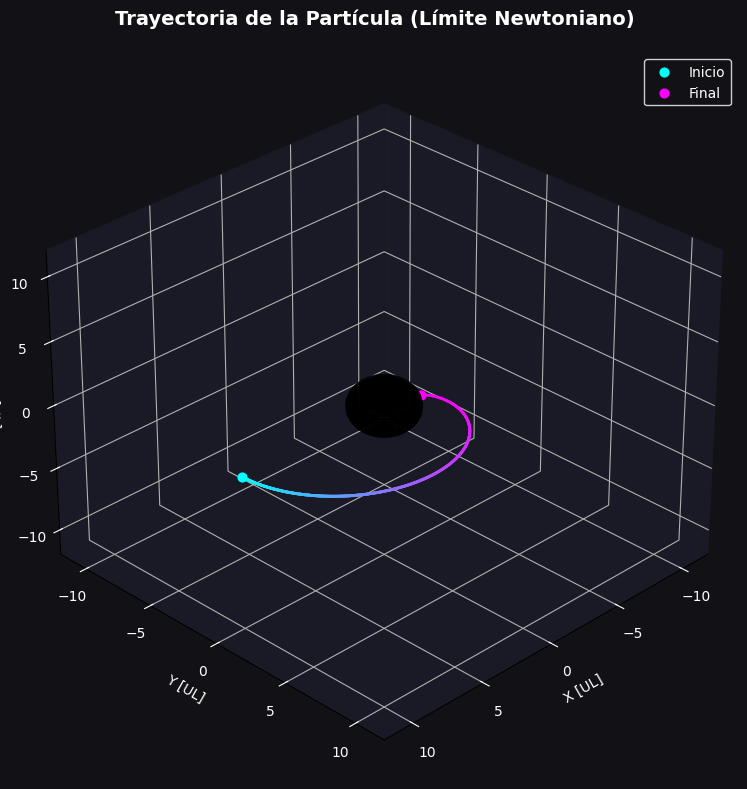

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- EXTRAER COORDENADAS DE LA PARTÍCULA DE CONTROL ---
x_p = solucion.y[1]
y_p = solucion.y[2]
z_p = solucion.y[3]
N_puntos = len(x_p)

# --- CREAR LA FIGURA 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Configuración del ángulo de visión (puedes ajustarlo a tu gusto)
ax.view_init(elev=30, azim=45)

# --- GRAFICAR LA TRAYECTORIA CON DEGRADADO (COLORMAP) ---
# Usamos un truco: graficamos pequeños segmentos para que cambien de color con el tiempo
# El color 'cool' va desde cyan (inicio) hasta magenta/rosado (final de la órbita)
cmap = plt.get_cmap('cool')
for i in range(N_puntos - 1):
    ax.plot(x_p[i:i+2], y_p[i:i+2], z_p[i:i+2], 
            color=cmap(i / N_puntos), alpha=0.8, linewidth=2.0)

# Marcamos explícitamente el punto inicial y final
ax.scatter(x_p[0], y_p[0], z_p[0], color='cyan', s=40, label='Inicio', zorder=5)
ax.scatter(x_p[-1], y_p[-1], z_p[-1], color='magenta', s=40, label='Final', zorder=5)

# --- DIBUJAR LA MASA CENTRAL (Radio de Schwarzschild como escala) ---
radio_horizonte = 2.0 * G * M / (c**2)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_bh = radio_horizonte * np.outer(np.cos(u), np.sin(v))
y_bh = radio_horizonte * np.outer(np.sin(u), np.sin(v))
z_bh = radio_horizonte * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.9, zorder=10)

# --- CONFIGURACIÓN ESTÉTICA EN FONDO OSCURO ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')

# Oscurecer los planos de los ejes
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

# Etiquetas de los ejes
ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

# Forzar ejes proporcionales basados en la posición inicial (con un margen)
lim = max(np.max(np.abs(x_p)), np.max(np.abs(y_p))) * 1.2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

# Título y leyenda
plt.title('Trayectoria de la Partícula (Límite Newtoniano)', 
          color='white', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', facecolor='#111116', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

### Integración de Múltiples Partículas

In [ ]:
#  CONFIGURACIÓN DEL DISCO 
N_particulas = 500
resultados_disco_3d = [] # Aquí guardaremos todas las órbitas

# Límites del disco: Radio interno y externo 
r_min = 5.0
r_max = 15.0



for i in range(N_particulas):
    # 1. Posición inicial aleatoria en el plano (z=0)
    r0 = np.random.uniform(r_min, r_max)
    phi = np.random.uniform(0, 2 * np.pi) 
    
    x0 = r0 * np.cos(phi)
    y0 = r0 * np.sin(phi)
    z0 = 0.0
    
    # Velocidad inicial (Órbita circular Kepleriana clásica)
    # v = sqrt(GM/r). La proyectamos perpendicular al radio vector.
    v_mag = np.sqrt(G * M / r0)
    vx0 = -v_mag * np.sin(phi)
    vy0 = v_mag * np.cos(phi)
    vz0 = 0.0
    
    # Normalización y Cuadrivelocidad inicial (documento del profesor)
    g00 = 1.0 - (2.0 * G * M) / (c**2 * r0)
    g11 = g22 = g33 = -1.0
    
    Ut0 = 1.0 / np.sqrt(g00 + g11*vx0**2 + g22*vy0**2 + g33*vz0**2)
    Ux0 = vx0 * Ut0 / c
    Uy0 = vy0 * Ut0 / c
    Uz0 = vz0 * Ut0 / c
    
    Y0 = [0.0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]
    
    # Tiempo de integración (1 órbita completa exacta por partícula usando Kepler)
    T_kepler = 2 * np.pi * np.sqrt(r0**3 / (G * M))
    # Reducimos los puntos a 200 por órbita para no saturar la memoria gráfica con 500 líneas
    taus = np.linspace(0, T_kepler, 200) 
    
    # 5. Integración numérica
    sol = solve_ivp(
        edg_newton, 
        [0.0, T_kepler], 
        Y0, 
        args=(G, M, c), 
        t_eval=taus, 
        method='Radau',
        rtol=1e-7,  # Relajamos un poco las tolerancias para hacer más rápida la ejecución masiva
        atol=1e-10
    )
    
    # Guardamos la trayectoria en la lista
    resultados_disco_3d.append(sol.y)
    


Simulando 500 partículas. Esto tomará algunos segundos...


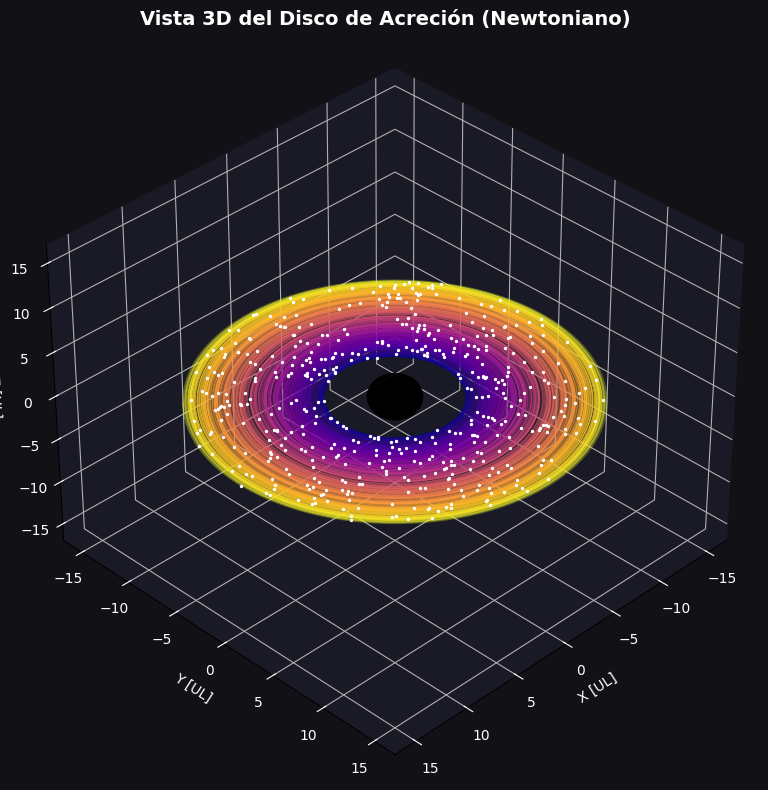

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- CONFIGURACIÓN DEL ÁNGULO ---
ax.view_init(elev=35, azim=45)

# --- DIBUJAR LAS 500 PARTÍCULAS ---
# Usamos un mapa de colores 'plasma' (naranja/morado) para colorearlas según su distancia
colores = cm.plasma(np.linspace(0, 1, len(resultados_disco_3d)))

for idx, y_particula in enumerate(resultados_disco_3d):
    x_p = y_particula[1]
    y_p = y_particula[2]
    z_p = y_particula[3]
    
    # Calculamos el radio promedio para darle color
    r_promedio = np.mean(np.sqrt(x_p**2 + y_p**2))
    color_asignado = cm.plasma((r_promedio - r_min) / (r_max - r_min))
    
    ax.plot(x_p, y_p, z_p, color=color_asignado, alpha=0.3, linewidth=0.8)
    ax.scatter(x_p[-1], y_p[-1], z_p[-1], color='white', s=2) # Puntos finales como "estrellas" o rocas

# --- DIBUJAR LA MASA CENTRAL ---
radio_horizonte = 2.0 * G * M / (c**2)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_bh = radio_horizonte * np.outer(np.cos(u), np.sin(v))
y_bh = radio_horizonte * np.outer(np.sin(u), np.sin(v))
z_bh = radio_horizonte * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.9, zorder=10)

# --- CONFIGURACIÓN ESTÉTICA ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')

ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

# Forzar ejes proporcionales
lim = r_max + 2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Vista 3D del Disco de Acreción (Newtoniano)', 
          color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Geodesiocas de Schwarzschild 